# Imports 

In [2]:
# Importing necessary libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime

# Sentiment Labeling Function

In [3]:
def sentiments_from_stars(stars, classification_type='three_class'):
    """
    Convert star ratings into sentiment labels.
    
    This function maps numerical star ratings (1-5) to sentiment categories.
    
    Parameters:
        stars (int): Star rating from 1 to 5
        classification_type (str): Either 'binary' or 'three_class'
            - 'binary': Only positive (4-5 stars) and negative (1-2 stars) (excludes neutral reviews from training)
            - 'three_class': Positive, neutral (3 stars), and negative
    
    Returns:
        str or None: Sentiment label ('positive', 'negative', 'neutral', or None)
    """
    if classification_type == 'binary':
        if stars >= 4:
            return 'positive'
        elif stars <= 2:
            return 'negative'
        else:
            return None
    else:
        if stars >= 4:
            return 'positive'
        elif stars == 3:
            return 'neutral'
        else:
            return 'negative'

# Data Loading and Preprocessing

In [4]:
# Load the cleaned dataset — make sure training_testing_dataset.csv is uploaded to this notebook's directory
df = pd.read_csv('training_testing_dataset.csv')

# Check if sentiment column exists, if not, generate it
if 'sentiment' not in df.columns:
    print("Preprocessing: Generating sentiment labels..")
    df['sentiment'] = df['stars'].apply(lambda x: sentiments_from_stars(x, 'three_class'))
    print("Sentiment labels added.\n")
else:
    print("Sentiment column already present. Skipping preprocessing.")

# Filter out records with missing sentiment labels
df_multi = df[df['sentiment'].notna()].copy()

# Separate features (review text) and labels (sentiment)
content = df_multi['clean_text']  # Review text content
sent = df_multi['sentiment']      # Sentiment labels

print(f"Total samples: {len(df_multi)}")
print(f"\nSentiment distribution:")
print(sent.value_counts())

Preprocessing: Generating sentiment labels..
Sentiment labels added.

Total samples: 14990

Sentiment distribution:
sentiment
positive    7049
negative    5955
neutral     1986
Name: count, dtype: int64


# Train-Test Split

In [5]:
# Split dataset: 80% training, 20% testing
# Stratification ensures proportional distribution of sentiment classes in both sets
content_train, content_test, sent_train, sent_test = train_test_split(
    content,
    sent,
    test_size=0.2,          # 20% reserved for model testing
    random_state=2016,      # Fixed seed for reproducible results
    stratify=sent           # Maintain sentiment distribution across splits
)

print(f"Dataset Split:")
print(f"  Training samples: {len(content_train)}")
print(f"  Test samples: {len(content_test)}")
print(f"\nTraining Sentiment Distribution:")
print(sent_train.value_counts())

Dataset Split:
  Training samples: 11992
  Test samples: 2998

Training Sentiment Distribution:
sentiment
positive    5639
negative    4764
neutral     1589
Name: count, dtype: int64


# Text Vectorization (TF-IDF)

In [11]:
# Convert text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency)
# This captures the importance of words relative to their frequency across all reviews
vectorizer = TfidfVectorizer(
    max_features=8000,      # # Use top 8,000 most significant terms
    ngram_range=(1, 2),     # Include both individual words and two-word phrases
    min_df=2,               # Exclude rare terms (appearing in fewer than 2 reviews)
    max_df=0.8              # Exclude common terms (appearing in more than 80% of reviews)
)
# Transform training data and learn vocabulary
content_train_tfidf = vectorizer.fit_transform(content_train)
# Transform test data using the same vocabulary (no additional learning)
content_test_tfidf = vectorizer.transform(content_test)
print(f"Text Vectorization:")
print(f"  Feature matrix shape: {content_train_tfidf.shape}")
print(f"  Vocabulary size: {len(vectorizer.vocabulary_)} unique terms")

Text Vectorization:
  Feature matrix shape: (11992, 8000)
  Vocabulary size: 8000 unique terms


# Model Training

In [12]:
# Initialize Logistic Regression classifier
model = LogisticRegression(
    max_iter=1000,              # Maximum iterations for model convergence
    random_state=2016,          # Fixed seed for reproducibility
    C=0.5,                      # Reduced from 1.0 for stronger regularization
    class_weight={'negative': 1, 'neutral': 2, 'positive': 1}  # Softer neutral boost vs 'balanced'
)
# Train the model on vectorized training data
model.fit(content_train_tfidf, sent_train)
# Extract feature importance for each sentiment class
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_  # Shape: (n_classes, n_features)
print(f"Model Configuration:")
print(f"  Algorithm: {type(model).__name__}")
print(f"  Classes: {list(model.classes_)}")
print(f"  class_weight: negative=1, neutral=2, positive=1")
print(f"  C: 0.5")
print("  Model training complete.")

Model Configuration:
  Algorithm: LogisticRegression
  Classes: ['negative', 'neutral', 'positive']
  class_weight: negative=1, neutral=2, positive=1
  C: 0.5
  Model training complete.


# Model Evalution 

In [13]:
# Generate predictions on the test set
sent_predict = model.predict(content_test_tfidf)

# Calculate performance metrics
accuracy = accuracy_score(sent_predict, sent_test)
cm = confusion_matrix(sent_test, sent_predict)

print(f"Total predictions made: {len(sent_predict)}")

Total predictions made: 2998


# Confusion Matrix 

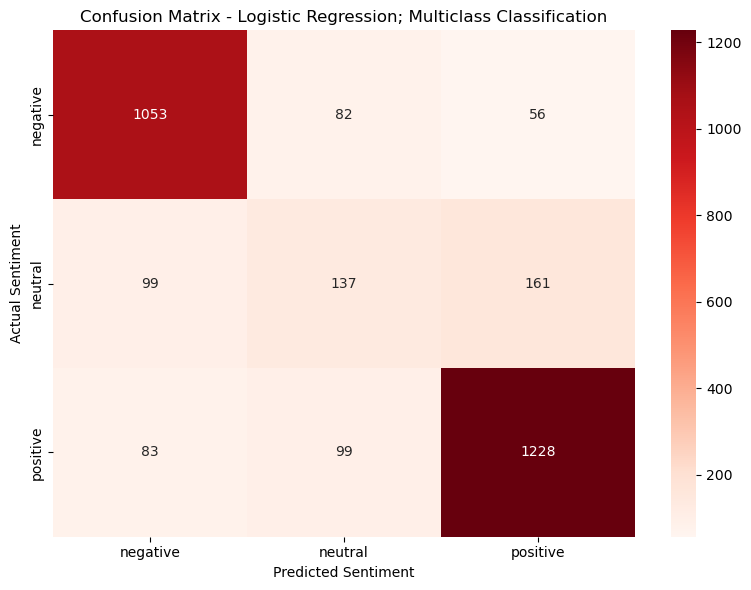

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
        xticklabels=model.classes_,
        yticklabels=model.classes_)
plt.title('Confusion Matrix - Logistic Regression; Multiclass Classification')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

# classification Report

In [15]:
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print('\nClassification Report:')
print(classification_report(sent_test, sent_predict))

print(f'Overall Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)')

print(f'\nConfusion Matrix:')
print(cm)

MODEL PERFORMANCE METRICS

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.88      0.87      1191
     neutral       0.43      0.35      0.38       397
    positive       0.85      0.87      0.86      1410

    accuracy                           0.81      2998
   macro avg       0.71      0.70      0.70      2998
weighted avg       0.80      0.81      0.80      2998

Overall Accuracy Score: 0.8065 (80.65%)

Confusion Matrix:
[[1053   82   56]
 [  99  137  161]
 [  83   99 1228]]


# Sentiment Distribution Comparison

In [16]:
print("Sentiment Distribution Comparison:")
print("=" * 50)
print("\nPredicted sentiment distribution:")
print(pd.Series(sent_predict).value_counts())
print("\nActual sentiment distribution:")
print(sent_test.value_counts())

Sentiment Distribution Comparison:

Predicted sentiment distribution:
positive    1445
negative    1235
neutral      318
Name: count, dtype: int64

Actual sentiment distribution:
sentiment
positive    1410
negative    1191
neutral      397
Name: count, dtype: int64


# Saving Model Predictions

In [19]:
# Save predictions to CSV with original text and actual sentiment
predictions_df = pd.DataFrame({
    'text': content_test.values,
    'actual_sentiment': sent_test.values,
    'predicted_sentiment': sent_predict
})

predictions_df.to_csv('multi_predicted_data.csv', index=False)
print(f"Predictions saved to multi_predicted_data.csv")

#Inspect Model Predictions
print(f"Total predictions: {len(predictions_df)}")
print("first 5 rows:")
predictions_df.head(5)

Predictions saved to multi_predicted_data.csv
Total predictions: 2998
first 5 rows:


,text,actual_sentiment,predicted_sentiment
0,this starbucks is always quick and efficient. ...,positive,positive
1,this is not a starbucks that i frequent becaus...,positive,positive
2,i love this little starbucks. the baristas are...,positive,positive
3,horrible service. they no longer have or try t...,negative,negative
4,wow. worst starbucks ever? i had them remake a...,negative,negative


# Vocabulary Data and Sentiment Associations

In [20]:
# Build vocabulary dataframe with sentiment associations
vocab_data = []
for idx, feature in enumerate(feature_names):
    # Get TF-IDF average importance
    tfidf_value = content_train_tfidf.mean(axis=0).A1[idx]
    
    # Get coefficients for this feature across all sentiments
    feature_coefs = coefficients[:, idx]
    
    # Find which sentiment this feature most strongly predicts
    max_sentiment_idx = np.argmax(np.abs(feature_coefs))
    primary_sentiment = model.classes_[max_sentiment_idx]
    sentiment_coefficient = feature_coefs[max_sentiment_idx]
    
    # Store all sentiment coefficients for reference
    coef_dict = {f'{s}_coef': feature_coefs[i]
                 for i, s in enumerate(model.classes_)}
    
    vocab_data.append({
        'Word/Phrase': feature,
        'TF-IDF_Average': tfidf_value,
        'Primary_Sentiment': primary_sentiment,
        'Sentiment_Coefficient': sentiment_coefficient,
        **coef_dict
    })

vocab_dataframe = pd.DataFrame(vocab_data)
vocab_dataframe = vocab_dataframe.sort_values(by=['TF-IDF_Average'], ascending=False)

# Save vocab data to CSV
vocab_dataframe.to_csv('multi_vocab_data.csv', index=False)
print(f"Vocabulary data saved to multi_vocab_data.csv")

Vocabulary data saved to multi_vocab_data.csv


# Exporting the Model and Vectorizer 

In [22]:
# Save the trained model
joblib.dump(model, 'sentiment_classification_model.pkl')

# Save the vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Success: Model saved as sentiment_classification_model.pkl")
print("Success: Vectorizer saved as tfidf_vectorizer.pkl")

Success: Model saved as sentiment_classification_model.pkl
Success: Vectorizer saved as tfidf_vectorizer.pkl
